In [16]:
%load_ext autoreload
%autoreload 2

In [44]:
import sys
import os

sys.path.insert(0, os.path.abspath("C://Users//pc//Desktop//Week 4//credit-risk-model//src//"))

In [45]:
from src.data_loader import load_data
from src.data_processing import *

print('Functions imported successfully!')
print()

Functions imported successfully!



### Load Data set

In [28]:
df = load_data('C:/Users/pc/Desktop/Week 4/credit-risk-model/data/raw/data.csv')
df.head()

,transactionid,batchid,accountid,subscriptionid,customerid,currencycode,countrycode,providerid,productid,productcategory,channelid,amount,value,transactionstarttime,pricingstrategy,fraudresult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


## Exploratory Data Analysis (EDA)

### 1.	Overview of the Data

In [ ]:
# Print the number of columns and rows
rows, cols = get_dataset_shape(df)

print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 95662
Columns: 16


In [ ]:
data_types = get_data_types(df)
print(data_types)

                  Column Data Type
0          transactionid       str
1                batchid       str
2              accountid       str
3         subscriptionid       str
4             customerid       str
5           currencycode       str
6            countrycode     int64
7             providerid       str
8              productid       str
9        productcategory       str
10             channelid       str
11                amount   float64
12                 value     int64
13  transactionstarttime       str
14       pricingstrategy     int64
15           fraudresult     int64


### 2.	Summary Statistics

In [ ]:
# To calculate the central tendency 
central_tendency = calculate_central_tendency(df)
print(central_tendency)

                        Mean  Median    Mode
countrycode       256.000000   256.0   256.0
amount           6717.846433  1000.0  1000.0
value            9900.583941  1000.0  1000.0
pricingstrategy     2.255974     2.0     2.0
fraudresult         0.002018     0.0     0.0


In [ ]:
# To calculate the dispersion 
dispersion_summary = calculate_dispersion(df)
print(dispersion_summary)

                      Range      Variance  Std_Deviation     IQR
countrycode             0.0  0.000000e+00       0.000000     0.0
amount           10880000.0  1.520457e+10  123306.797164  2850.0
value             9879998.0  1.515905e+10  123122.087776  4725.0
pricingstrategy         4.0  5.371778e-01       0.732924     0.0
fraudresult             1.0  2.013471e-03       0.044872     0.0


In [ ]:
# To calculate the shape of the dataset’s distribution
shape_stats = distribution_shape(df)
print(shape_stats)

                  Skewness     Kurtosis
countrycode       0.000000     0.000000
amount           51.098490  3363.127739
value            51.291086  3378.069274
pricingstrategy   1.659057     2.087534
fraudresult      22.196295   490.685762


### 3.	Distribution of Numerical Features

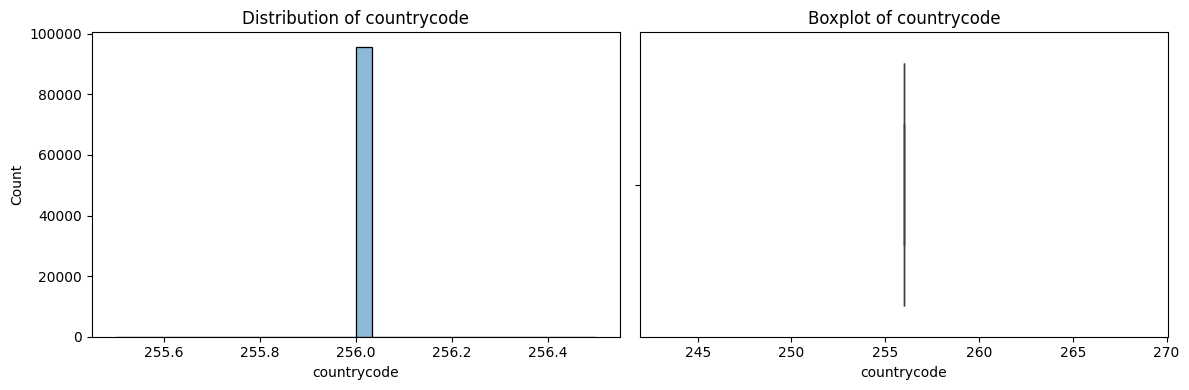

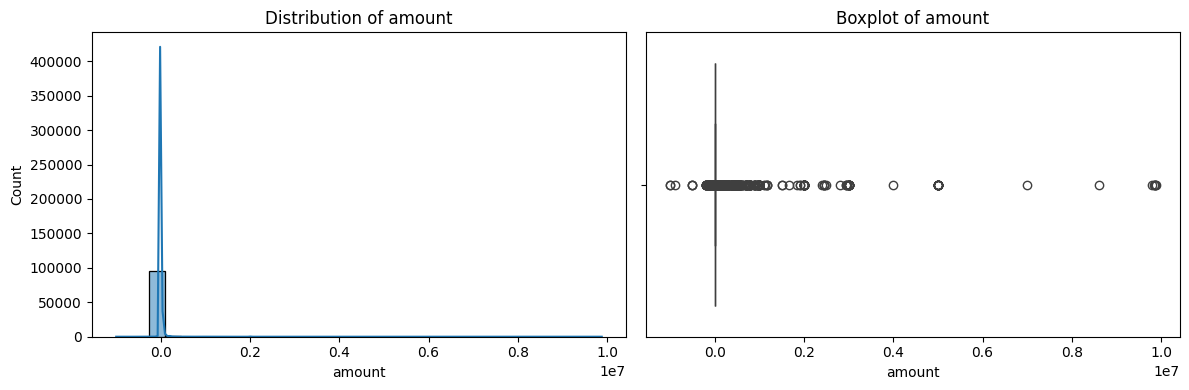

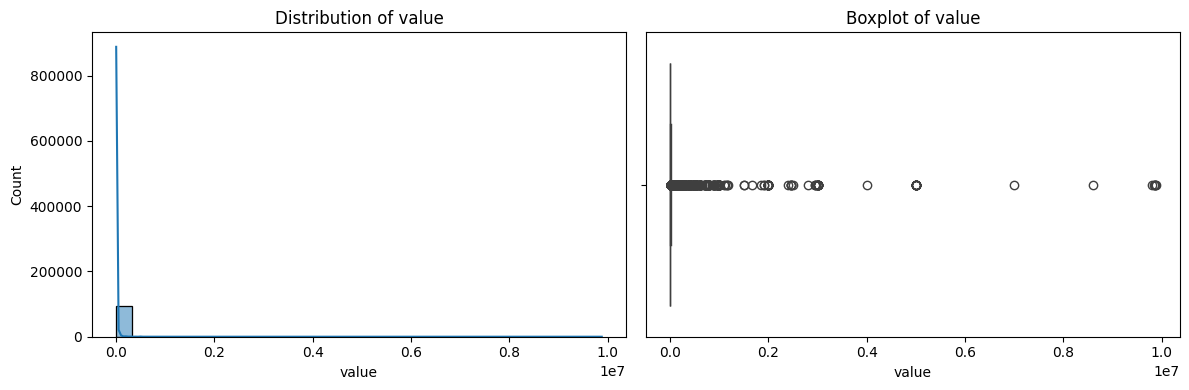

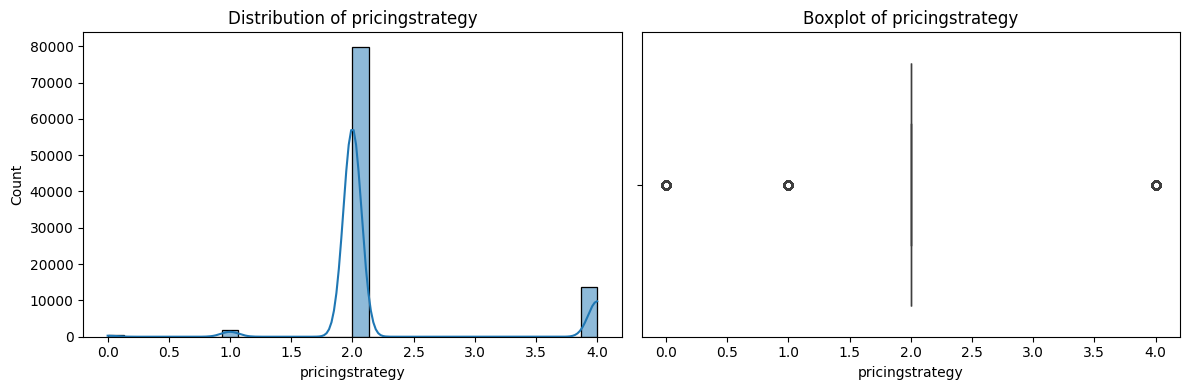

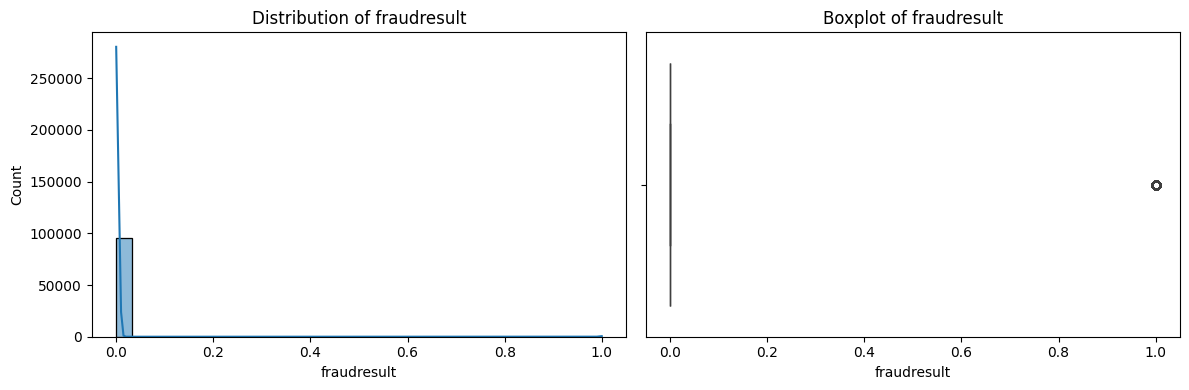


Skewness Summary:
           Feature   Skewness
0      countrycode   0.000000
1           amount  51.098490
2            value  51.291086
3  pricingstrategy   1.659057
4      fraudresult  22.196295


In [ ]:
# Distribution analysis
skewness_report = analyze_distributions(df)

print("\nSkewness Summary:")
print(skewness_report)

### 4.	Distribution of Categorical Features

In [ ]:
# Categorical variability analysis
variability_report = categorical_variability(df)
print(variability_report)

                 Feature  Unique Categories Most Frequent Category  \
0          transactionid              95662        TransactionId_1   
1                batchid              94809          BatchId_67019   
2              accountid               3633         AccountId_4841   
3         subscriptionid               3627    SubscriptionId_3829   
4             customerid               3742        CustomerId_7343   
5           currencycode                  1                    UGX   
6             providerid                  6           ProviderId_4   
7              productid                 23            ProductId_6   
8        productcategory                  9     financial_services   
9              channelid                  4            ChannelId_3   
10  transactionstarttime              94556   2018-12-24T16:30:13Z   

    Most Frequent Count  
0                     1  
1                    28  
2                 30893  
3                 32630  
4                  4091  
5  

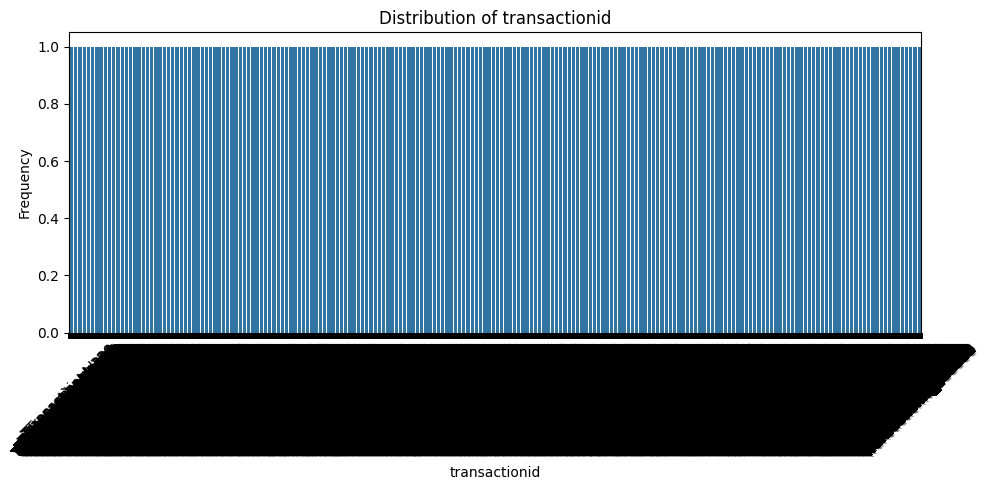

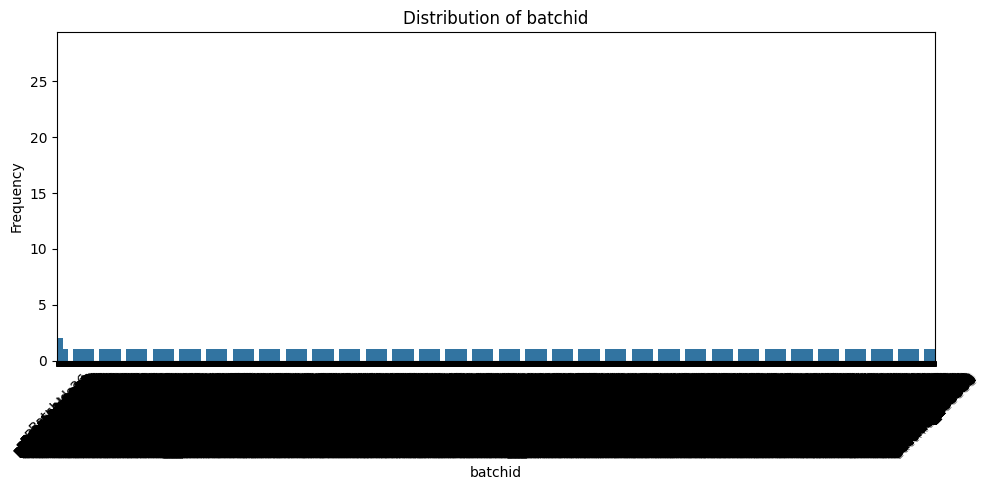

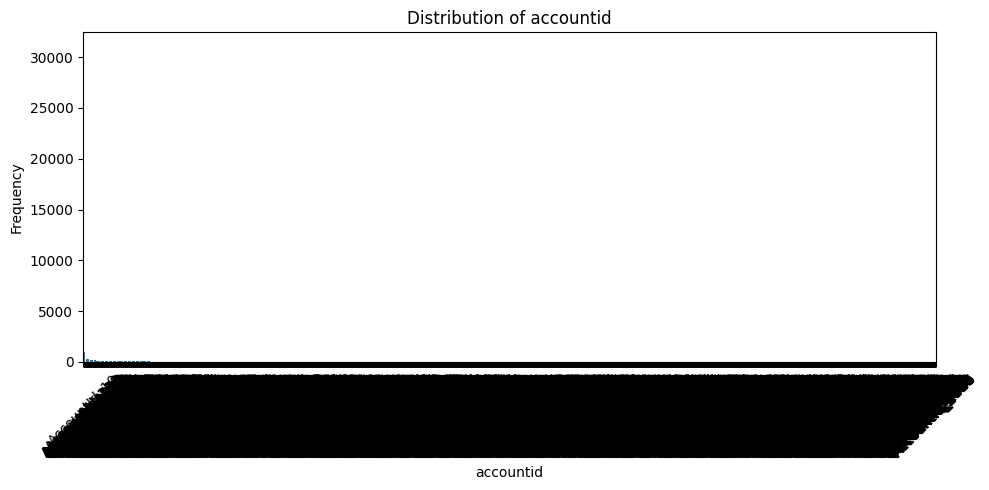

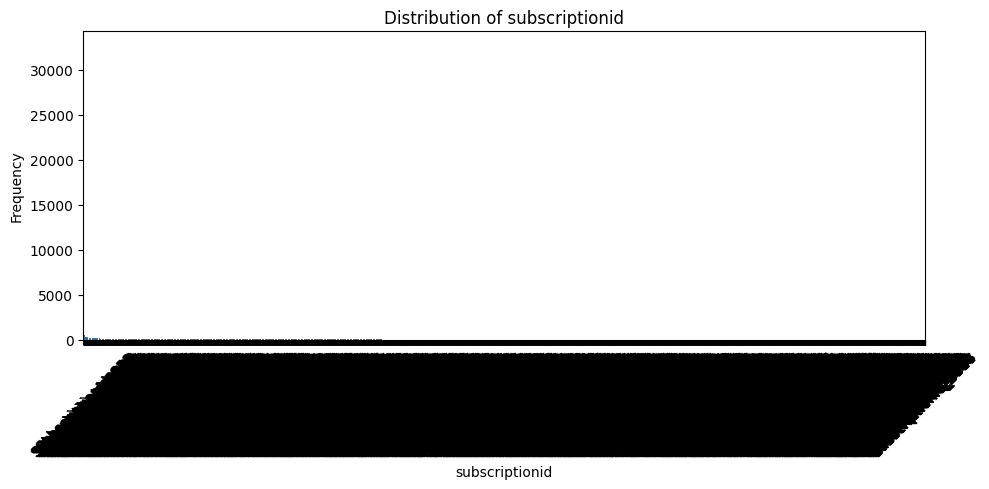

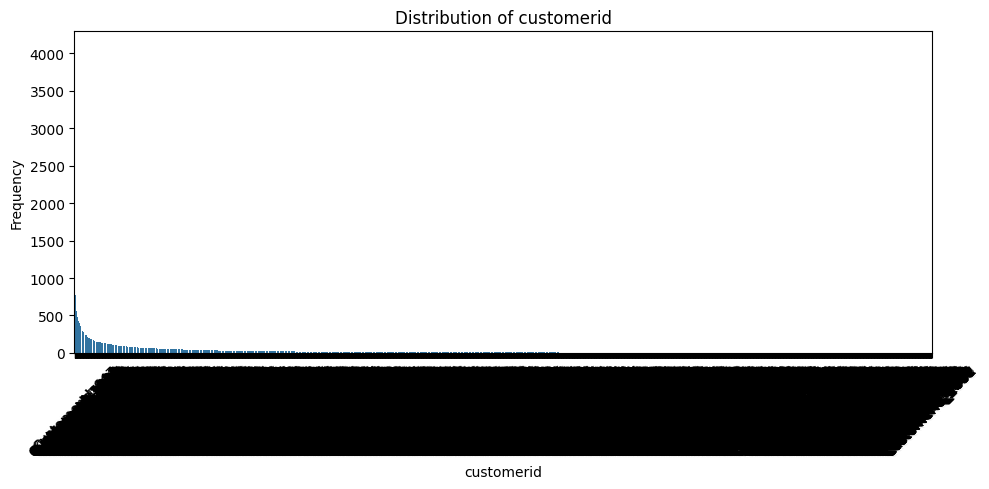

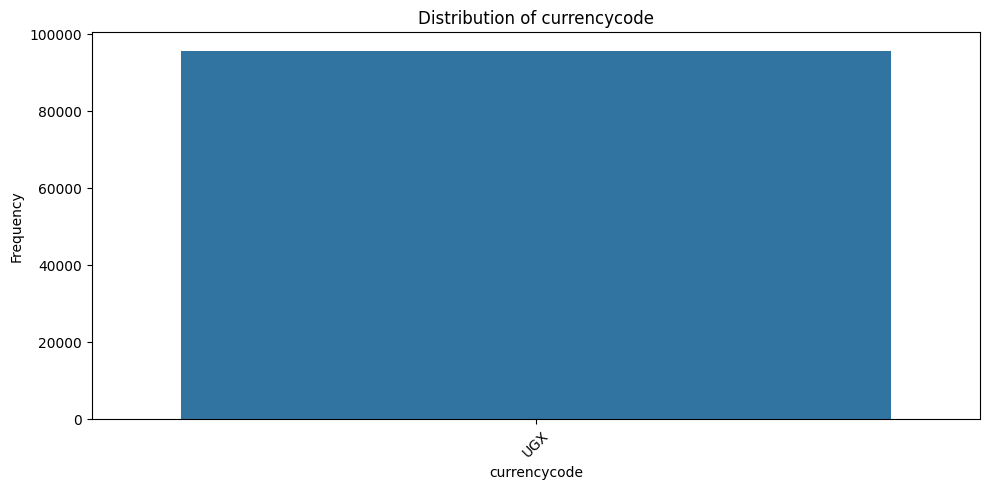

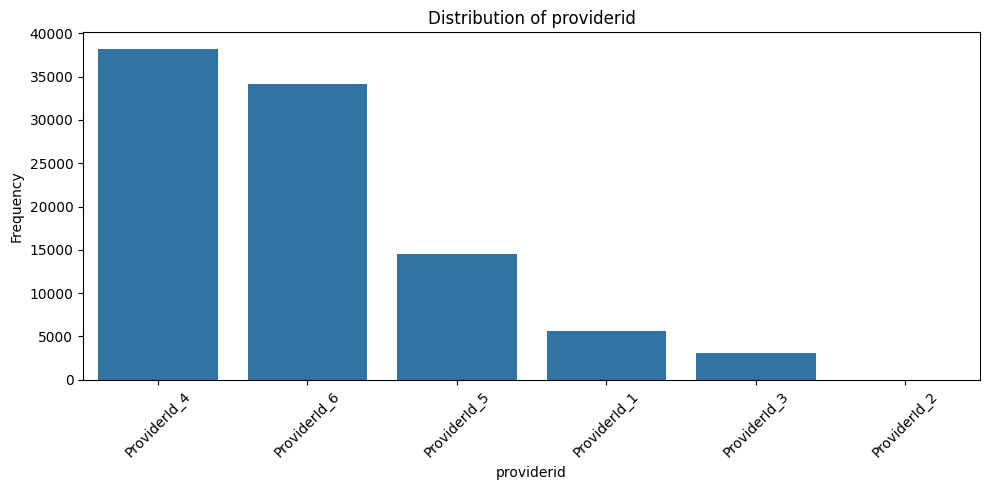

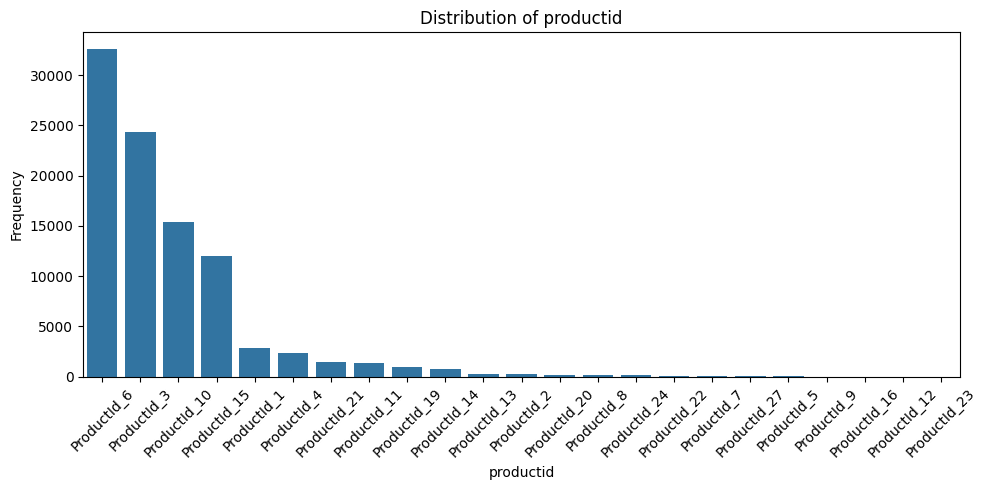

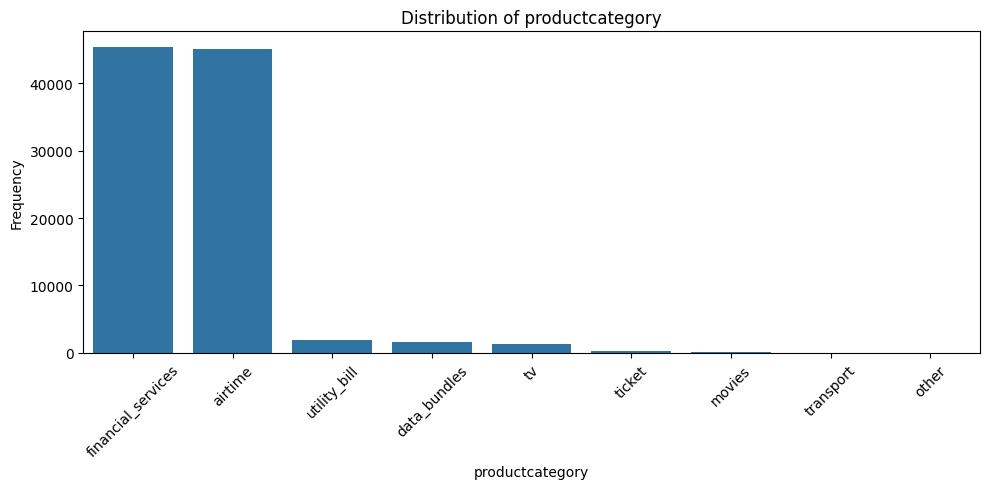

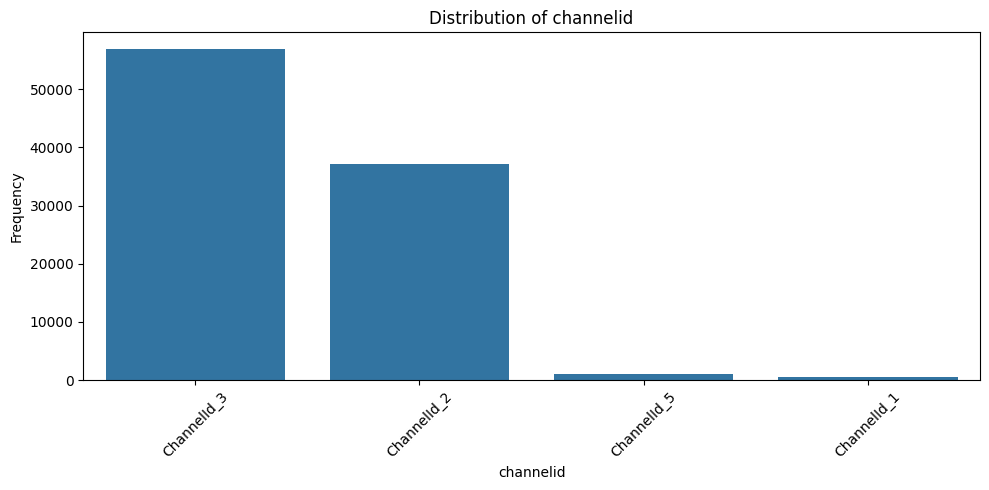

: 

In [ ]:
plot_all_categorical_distributions(df)

### 5.	Correlation Analysis


🔹 Numerical Features:
['countrycode', 'amount', 'value', 'pricingstrategy', 'fraudresult']

🔹 Correlation Matrix:
                 countrycode    amount     value  pricingstrategy  fraudresult
countrycode              NaN       NaN       NaN              NaN          NaN
amount                   NaN  1.000000  0.989692        -0.061931     0.557370
value                    NaN  0.989692  1.000000        -0.017020     0.566739
pricingstrategy          NaN -0.061931 -0.017020         1.000000    -0.033821
fraudresult              NaN  0.557370  0.566739        -0.033821     1.000000

🔹 High Correlation Pairs:
  Feature_1 Feature_2  Correlation
0     value    amount     0.989692

🔹 Heatmap:


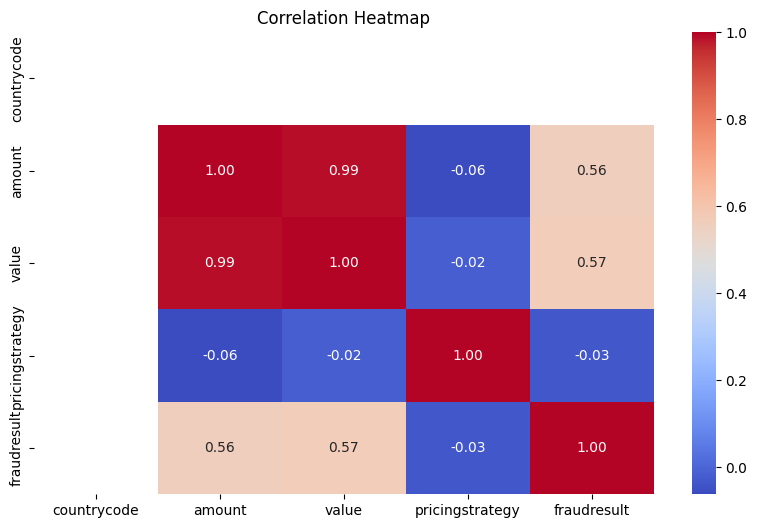

In [ ]:

corr_matrix, strong_pairs = correlation_analysis(df, threshold=0.8)

In [14]:
missing_report = missing_value_analysis(df)


🔹 Missing Value Summary:
                          Missing_Count  Missing_Percentage  \
transactionid                         0                 0.0   
batchid                               0                 0.0   
accountid                             0                 0.0   
subscriptionid                        0                 0.0   
customerid                            0                 0.0   
currencycode                          0                 0.0   
countrycode                           0                 0.0   
providerid                            0                 0.0   
productid                             0                 0.0   
productcategory                       0                 0.0   
channelid                             0                 0.0   
amount                                0                 0.0   
value                                 0                 0.0   
transactionstarttime                  0                 0.0   
pricingstrategy              

c:\Users\pc\Desktop\Week 4\credit-risk-model\src\data_processing.py:452: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Feature Engineering

### 1.	Create Aggregate Features

In [5]:
#Total Transaction Amount
total_transaction_amount = calculate_total_transaction_amount(
    df,
    customer_col="customerid",
    amount_col="amount"
)

print(total_transaction_amount.head())

        customerid  Total_Transaction_Amount
0     CustomerId_1                  -10000.0
1    CustomerId_10                  -10000.0
2  CustomerId_1001                   20000.0
3  CustomerId_1002                    4225.0
4  CustomerId_1003                   20000.0


In [6]:
# Average Transaction Amount
avg_transaction_amount = calculate_average_transaction_amount(
    df,
    customer_col="customerid",
    amount_col="amount"
)

print(avg_transaction_amount.head())

        customerid  Average_Transaction_Amount
0     CustomerId_1               -10000.000000
1    CustomerId_10               -10000.000000
2  CustomerId_1001                 4000.000000
3  CustomerId_1002                  384.090909
4  CustomerId_1003                 3333.333333


In [7]:
# Transaction Count
transaction_count = calculate_transaction_count(
    df,
    customer_col="customerid"
)

print(transaction_count.head())

        customerid  Transaction_Count
0     CustomerId_1                  1
1    CustomerId_10                  1
2  CustomerId_1001                  5
3  CustomerId_1002                 11
4  CustomerId_1003                  6


In [8]:
# Standard Deviation of Transaction Amounts
std_feature = calculate_transaction_amount_std(
    df,
    customer_col="customerid",
    amount_col="amount"
)

print(std_feature.head())

        customerid  Transaction_Amount_Std
0     CustomerId_1                     NaN
1    CustomerId_10                     NaN
2  CustomerId_1001             6558.963333
3  CustomerId_1002              560.498966
4  CustomerId_1003             6030.478146


### 2.	Extract Features

In [9]:
df.columns

Index(['transactionid', 'batchid', 'accountid', 'subscriptionid', 'customerid',
       'currencycode', 'countrycode', 'providerid', 'productid',
       'productcategory', 'channelid', 'amount', 'value',
       'transactionstarttime', 'pricingstrategy', 'fraudresult'],
      dtype='str')

In [10]:
# Transaction Hour
df = add_transaction_hour_feature(
    df,
    datetime_col="transactionstarttime"
)

print(df[["transactionstarttime", "Transaction_Hour"]].head())

       transactionstarttime  Transaction_Hour
0 2018-11-15 02:18:49+00:00                 2
1 2018-11-15 02:19:08+00:00                 2
2 2018-11-15 02:44:21+00:00                 2
3 2018-11-15 03:32:55+00:00                 3
4 2018-11-15 03:34:21+00:00                 3


In [11]:
# Transaction Day
df = add_transaction_day_of_month_feature(
    df,
    datetime_col="transactionstarttime"
)

print(df[["transactionstarttime", "Transaction_Day_of_Month"]].head())

       transactionstarttime  Transaction_Day_of_Month
0 2018-11-15 02:18:49+00:00                        15
1 2018-11-15 02:19:08+00:00                        15
2 2018-11-15 02:44:21+00:00                        15
3 2018-11-15 03:32:55+00:00                        15
4 2018-11-15 03:34:21+00:00                        15


In [12]:
# Transaction Month
df = add_transaction_month_feature(
    df,
    datetime_col="transactionstarttime"
)

print(df[["transactionstarttime", "Transaction_Month"]].head())

       transactionstarttime  Transaction_Month
0 2018-11-15 02:18:49+00:00                 11
1 2018-11-15 02:19:08+00:00                 11
2 2018-11-15 02:44:21+00:00                 11
3 2018-11-15 03:32:55+00:00                 11
4 2018-11-15 03:34:21+00:00                 11


In [13]:
# Transaction Year
df = add_transaction_year_feature(
    df,
    datetime_col="transactionstarttime"
)

print(df[["transactionstarttime", "Transaction_Year"]].head())

       transactionstarttime  Transaction_Year
0 2018-11-15 02:18:49+00:00              2018
1 2018-11-15 02:19:08+00:00              2018
2 2018-11-15 02:44:21+00:00              2018
3 2018-11-15 03:32:55+00:00              2018
4 2018-11-15 03:34:21+00:00              2018


### 3.	Encode Categorical Variables

In [15]:
# Identify categorical features
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical features:", categorical_features)

Categorical features: ['transactionid', 'batchid', 'accountid', 'subscriptionid', 'customerid', 'currencycode', 'providerid', 'productid', 'productcategory', 'channelid']


In [24]:
# One-Hot Encoding
df_hot = one_hot_encode_multiple(
    df,
    columns=["currencycode", "productcategory"],
    drop_first=False
)

print(df_hot.head())

         transactionid         batchid       accountid       subscriptionid  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        customerid  countrycode    providerid     productid    channelid  \
0  CustomerId_4406          256  ProviderId_6  ProductId_10  ChannelId_3   
1  CustomerId_4406          256  ProviderId_4   ProductId_6  ChannelId_2   
2  CustomerId_4683          256  ProviderId_6   ProductId_1  ChannelId_3   
3   CustomerId_988          256  ProviderId_1  ProductId_21  ChannelId_3   
4   CustomerId_988          256  ProviderId_4   ProductId_6  ChannelId_2   

    amount  ...  currencycode_UGX productcategory_airtime  \
0   100

In [26]:
# Label Encoding
df_encod, encoders = label_encode_multiple(
    df,
    columns=["currencycode", "productcategory"]
)

print(df_encod.head())

         transactionid         batchid       accountid       subscriptionid  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        customerid currencycode  countrycode    providerid     productid  \
0  CustomerId_4406          UGX          256  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX          256  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX          256  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX          256  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX          256  ProviderId_4   ProductId_6   

      productcategory    channelid   amount  value  transactionstart

### 4.	Handle Missing Values

In [27]:
# Mean imputation
df = impute_missing_values(df, strategy="mean")

In [28]:
# Median imputation
df = impute_missing_values(df, strategy="median")

In [31]:
df.columns

Index(['transactionid', 'batchid', 'accountid', 'subscriptionid', 'customerid',
       'currencycode', 'countrycode', 'providerid', 'productid',
       'productcategory', 'channelid', 'amount', 'value',
       'transactionstarttime', 'pricingstrategy', 'fraudresult'],
      dtype='str')

In [32]:
# Mode imputation (categorical or numeric)
df = impute_missing_values(df, strategy="mode", columns=["amount"])

In [33]:
# KNN imputation
df = impute_missing_values(df, strategy="knn", n_neighbors=3)

In [34]:
# Drop rows with any missing values
df_clean = drop_missing_rows(df)

In [35]:
# Drop rows only if specific columns have missing values
df_clean = drop_missing_rows(df, subset=["amount", "customerid"])

In [36]:
# Drop columns with more than 50% missing values
df_clean = drop_missing_columns(df, threshold=int(len(df) * 0.5))

### 5. Normalize/Standardize Numerical Features

In [39]:
# Normalize all numeric columns
df_norm = normalize_minmax(df)

# Normalize specific columns
df_norm = normalize_minmax(df, columns=["amount"])

print(df_norm.head())

         transactionid         batchid       accountid       subscriptionid  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        customerid currencycode  countrycode    providerid     productid  \
0  CustomerId_4406          UGX        256.0  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX        256.0  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX        256.0  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX        256.0  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX        256.0  ProviderId_4   ProductId_6   

      productcategory    channelid    amount    value  transactionst

In [40]:
# Standardize all numeric columns
df_std = standardize_data(df)

print(df_std.head())

         transactionid         batchid       accountid       subscriptionid  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        customerid currencycode  countrycode    providerid     productid  \
0  CustomerId_4406          UGX          0.0  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX          0.0  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX          0.0  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX          0.0  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX          0.0  ProviderId_4   ProductId_6   

      productcategory    channelid    amount     value  transactions

### 6. Feature Engineering with WoE and IV

## Proxy Target Variable Engineering

### 1.	Calculate RFM Metrics

In [5]:
df.columns

Index(['transactionid', 'batchid', 'accountid', 'subscriptionid', 'customerid',
       'currencycode', 'countrycode', 'providerid', 'productid',
       'productcategory', 'channelid', 'amount', 'value',
       'transactionstarttime', 'pricingstrategy', 'fraudresult'],
      dtype='str')

In [6]:
rfm_df = calculate_rfm(
    df,
    customer_col="customerid",
    date_col="transactionstarttime",
    amount_col="amount"
)

print(rfm_df.head())

        customerid  Recency  Frequency  Monetary
0     CustomerId_1       83          1  -10000.0
1    CustomerId_10       83          1  -10000.0
2  CustomerId_1001       89          5   20000.0
3  CustomerId_1002       25         11    4225.0
4  CustomerId_1003       11          6   20000.0


In [29]:
snapshot_date = define_snapshot_date(
    df,
    date_col="transactionstarttime",
    method="dynamic"
)

print(snapshot_date)

2019-02-14 10:01:28+00:00


### 2.	Cluster Customers

In [33]:
rfm_segmented, kmeans_model = segment_customers_by_rfm(
    rfm_df,
    n_clusters=3,
    random_state=42
)

print(rfm_segmented.head())

        customerid  Recency  Frequency  Monetary  Customer_Segment
0     CustomerId_1       83          1  -10000.0                 0
1    CustomerId_10       83          1  -10000.0                 0
2  CustomerId_1001       89          5   20000.0                 0
3  CustomerId_1002       25         11    4225.0                 1
4  CustomerId_1003       11          6   20000.0                 1


In [36]:
segment_summary = summarize_segments(rfm_segmented)
print(segment_summary)

                  Recency  Frequency      Monetary
Customer_Segment                                  
0                   60.88       7.72  8.172068e+04
1                   11.73      34.80  2.725740e+05
2                   28.00    4091.00 -1.049000e+08


### 3.	Define and Assign the "High-Risk" Label

In [40]:
rfm_target, cluster_summary, high_risk_cluster = (
    generate_high_risk_target(rfm_segmented)
)

print("High-Risk Cluster:", high_risk_cluster)

High-Risk Cluster: 2


In [41]:
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
                  Recency  Frequency      Monetary
Customer_Segment                                  
0                   60.88       7.72  8.172068e+04
1                   11.73      34.80  2.725740e+05
2                   28.00    4091.00 -1.049000e+08


In [42]:
print("\nTarget Distribution:")
print(rfm_target["is_high_risk"].value_counts())


Target Distribution:
is_high_risk
0    3741
1       1
Name: count, dtype: int64


In [43]:
print(rfm_target.head())

        customerid  Recency  Frequency  Monetary  Customer_Segment  \
0     CustomerId_1       83          1  -10000.0                 0   
1    CustomerId_10       83          1  -10000.0                 0   
2  CustomerId_1001       89          5   20000.0                 0   
3  CustomerId_1002       25         11    4225.0                 1   
4  CustomerId_1003       11          6   20000.0                 1   

   is_high_risk  
0             0  
1             0  
2             0  
3             0  
4             0  


### 4.	Integrate the Target Variable

In [48]:
processed_df = merge_high_risk_target(
    main_df=df,
    rfm_target_df=rfm_target,
    customer_col="customerid"
)

print(processed_df.head())

         transactionid         batchid       accountid       subscriptionid  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        customerid currencycode  countrycode    providerid     productid  \
0  CustomerId_4406          UGX          256  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX          256  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX          256  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX          256  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX          256  ProviderId_4   ProductId_6   

      productcategory    channelid   amount  value  transactionstart

In [49]:
output_file = "data/processed/processed_data.csv"
processed_df.to_csv(output_file, index=False)